
 #### Práctica 1: Análisis exploratorio de dataset
 # Diabetes en México

### Introducción
La diabetes mellitus comprende un grupo de enfermedades metabólicas cuyo principal rasgo en común es la hiperglucemia, es decir, una concentración de glucosa en sangre superior a los valores normales. Esta alteración puede deberse a una deficiencia en la secreción de insulina, a una disminución en la eficacia de su acción metabólica o a una combinación de ambos factores. Cuando la hiperglucemia se mantiene de forma prolongada, puede provocar diversas complicaciones crónicas y ocasionar daños progresivos en distintos órganos y tejidos, particularmente en los vasos sanguíneos, los nervios y el sistema cardiovascular. (De Santiago Nocito, 2010)

En 2021, se estimó que aproximadamente 529 millones de personas vivían con diabetes tipo 2 en el mundo, lo que representaba alrededor del 6.1 % de la población mundial. Asimismo, se proyecta que para 2050 esta cifra podría alcanzar aproximadamente 1,300 millones de personas, equivalente al 9.8 % de la población. En América Latina, y particularmente en México, la elevada prevalencia de la DT2 representa un desafío relevante, no solo por las complicaciones asociadas y su impacto en la calidad de vida de la población, sino también por la carga económica que genera para los sistemas de salud y la sociedad. (Hernández-Ávila, M, 2013)

Bajo este contexto, se va hacer análisis exploratorio de un dataset a partir de información pública proveniente de la Encuesta Nacional de Salud y Nutrición (ENSANUT) 2024, realizada en México y publicada por el Instituto Nacional de Salud Pública (INSP). La ENSANUT recopila información sobre las condiciones de salud y nutrición de la población mexicana mediante cuestionarios, mediciones antropométricas y, para determinados participantes, la obtención y análisis de muestras biológicas. (Reyes-García, A, et al., 2025) (Encuesta Nacional de Salud y Nutrición, 2024)

### Dataset
El dataset utilizado integra información demográfica, antropométrica y bioquímica de 2,549 participantes, con el propósito de analizar distintos factores asociados con la diabetes y clasificar el nivel de riesgo que presenta cada individuo de desarrollar esta enfermedad. El conjunto de datos está compuesto por 24 atributos, los cuales incluyen variables de identificación, variables categóricas y numéricas.(Jiménez & Lee, 2026)

| Atributo | Descripción |
|---|---|
| folio_i | Identificador único del hogar |
| folio_int | Identificador único del individuo | 
| sexo | Sexo del individuo (1 = masculino, 2 = femenino) | 
| edad | Edad del individuo en años |
| Ciudad | Ciudad de residencia | 
| Peso | Peso corporal en kilogramos | 
| Estatura | Estatura del individuo en centímetros | 
| imc | Índice de masa corporal (IMC) | Numérica continua |
| muestra_suero | Indica si se obtuvo una muestra de suero (0 = no, 1 = sí) |
| ac_urico | Concentración de ácido úrico en sangre | 
| albu | Concentración de albúmina en sangre | 
| col_hdl | Nivel de colesterol HDL | 
| col_ldl | Nivel de colesterol LDL | 
| colest | Nivel de colesterol total | 
| creat | Nivel de creatinina | 
| glu_suero | Concentración de glucosa sérica | 
| insulina | Concentración de insulina en sangre | 
| trig | Nivel de triglicéridos | 
| hb1ac | Hemoglobina glucosilada (HbA1c) | 
| ponde_venosa | Ponderador correspondiente a la muestra venosa | 
| estrato | Estrato utilizado en el diseño muestral | 
| est_sel | Unidad primaria de muestreo |
| ponde_hemo | Ponderador correspondiente a la muestra de hemoglobina 
| riesgo_diabetes_cat | Categoría de riesgo de diabetes (0 = bajo, 1 = moderado, 2 = alto) |


#### Librerias

In [ ]:
!pip install numpy pandas matplotlib seaborn 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Análisis demográfico: ciudades y sexo

Cantidad de ciudades diferentes: 267

Ciudades más frecuentes:
Ciudad
AGUASCALIENTES    81
MONTERREY         54
JUAREZ            46
TIJUANA           43
MATAMOROS         36
Name: count, dtype: int64


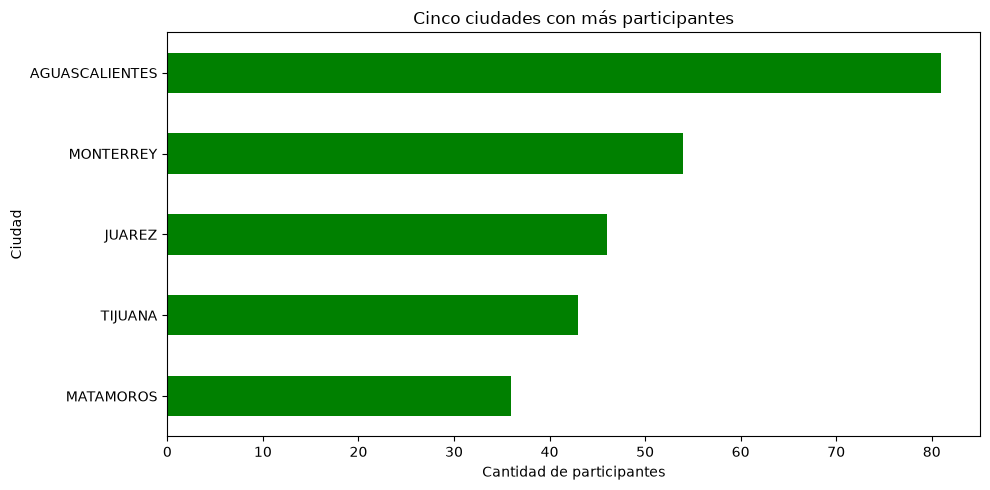


Cantidad de participantes por sexo:
sexo
Mujer     1547
Hombre    1002
Name: count, dtype: int64


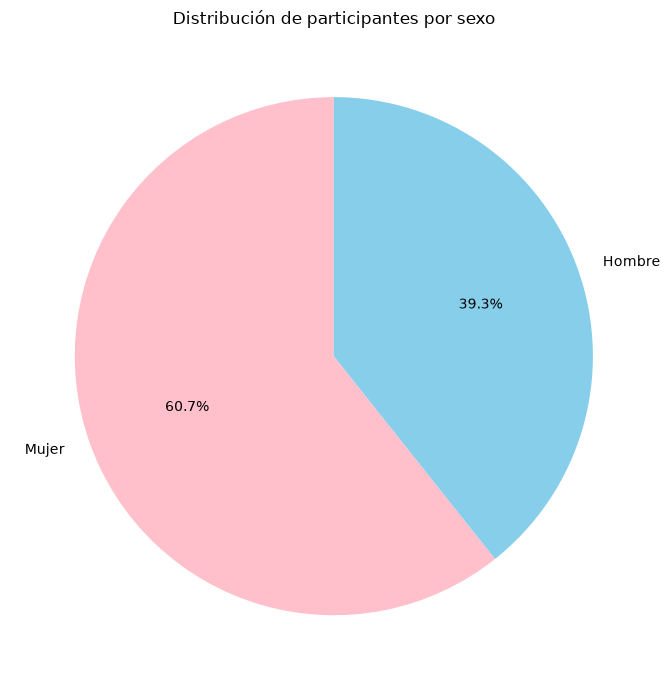

In [3]:
df= pd.read_csv('Diabetes_Mexico.csv')
# Cantidad de ciudades diferentes
cantidad_ciudades = df['Ciudad'].nunique()
print(f'Cantidad de ciudades diferentes: {cantidad_ciudades}')

# Lista de las cinco ciudades que más se repiten
ciudades_mas_frecuentes = df['Ciudad'].value_counts().head(5)
print('\nCiudades más frecuentes:')
print(ciudades_mas_frecuentes)

# Gráfica de barras de las ciudades más frecuentes
plt.figure(figsize=(10,5))
ciudades_mas_frecuentes.sort_values().plot(kind='barh', color='green')
plt.title('Cinco ciudades con más participantes')
plt.xlabel('Cantidad de participantes')
plt.ylabel('Ciudad')
plt.tight_layout()
plt.show()

# Conteo de participantes por sexo
conteo_sexo = df['sexo'].value_counts()
print('\nCantidad de participantes por sexo:')
print(conteo_sexo)

# Gráfica de pastel de la distribución por sexo
plt.figure(figsize=(7, 7))
conteo_sexo.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['pink', 'skyblue']
)
plt.title('Distribución de participantes por sexo')
plt.ylabel('')
plt.tight_layout()
plt.show()

A partir del análisis demográfico, se observa que las ciudades con mayor participación en el dataset se concentran principalmente en el norte del país. Asimismo, se identifica una mayor representación de mujeres en comparación con los hombres, lo que indica que la distribución de los participantes por sexo no es uniforme.

### Variable objetivo
La variable objetivo del dataset correspondiente al riesgo de diabetes. Esta variable permite clasificar a los participantes de acuerdo con su nivel de riesgo que se divide en tres categorías (0, 1 y 2) y permite analizar cómo distintas características demográficas, antropométricas y bioquímicas se relacionan con los diferentes niveles de riesgo.

Cantidad de participantes por categoría de riesgo:
Riesgo 0    1697
Riesgo 1      12
Riesgo 2     840
Name: count, dtype: int64


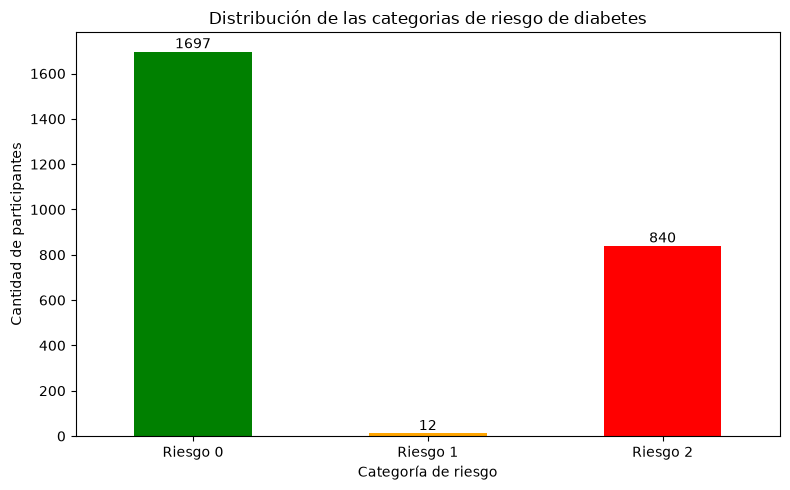

In [6]:
# Conteo de participantes por categoría de riesgo de diabetes
riesgo_diabetes = pd.to_numeric(df['riesgo_diabetes_cat'], errors='coerce')
conteo_riesgo = riesgo_diabetes.value_counts().reindex([0, 1, 2], fill_value=0).sort_index()
conteo_riesgo.index = ['Riesgo 0', 'Riesgo 1', 'Riesgo 2']

print('Cantidad de participantes por categoría de riesgo:')
print(conteo_riesgo)

# Gráfica de barras de las categorías de riesgo
plt.figure(figsize=(8, 5))
ax = conteo_riesgo.plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Distribución de las categorias de riesgo de diabetes')
plt.xlabel('Categoría de riesgo')
plt.ylabel('Cantidad de participantes')
plt.xticks(rotation=0)

for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

Al analizar su distribución, se observa un desbalance considerable entre las categorías. La categoría 0 concentra la mayor cantidad de participantes, con 1,697 registros, seguida de la categoría 2 con 840, mientras que la categoría 1 cuenta únicamente con 12 observaciones. Este aspecto deberá considerarse al interpretar las comparaciones entre grupos, especialmente en el caso de la categoría 1, ya que su reducido número de observaciones puede limitar la representatividad

### Calidad de los datos númericos

In [71]:
describe = df.describe()
describe

,edad,imc,muestra_suero,col_ldl,colest,glu_suero,trig,hb1ac,estrato,est_sel,riesgo_diabetes_cat
count,2524.000000,35.000000,2549.0,2549.000000,2549.000000,2549.000000,2549.000000,241.000000,2549.000000,2549.000000,2549.000000
mean,35.763074,29.971429,1.0,91.143978,143.023146,105.541389,153.564143,5.809129,2.088662,167.799137,0.663790
std,319.672846,7.633077,0.0,29.904939,42.458243,51.922275,126.311311,1.450890,0.825411,94.420560,0.939469
min,-7975.000000,15.000000,1.0,16.000000,25.000000,32.000000,24.000000,5.000000,1.000000,11.000000,0.000000
25%,34.000000,25.000000,1.0,71.000000,115.000000,83.000000,87.000000,5.000000,1.000000,83.000000,0.000000
50%,47.500000,30.000000,1.0,88.000000,139.000000,92.000000,123.000000,5.000000,2.000000,172.000000,0.000000
75%,62.000000,32.500000,1.0,108.000000,166.000000,104.000000,181.000000,6.000000,3.000000,242.000000,2.000000
max,95.000000,56.000000,1.0,354.000000,625.000000,1116.000000,2834.000000,12.000000,3.000000,323.000000,2.000000


#### Errores en la captura de datos: Edad fuera de rango
Como se puede observar, algunas de las variables presentan ciertas irregularidades. La tabla muestra únicamente los atributos numéricos y permite identificar, en primer lugar, la presencia de valores faltantes. Un ejemplo de ello es la variable edad, cuyo count indica que se dispone de información para 2,524 de los 2,549 participantes del dataset. Esto significa que 25 registros no cuentan con información para esta variable, lo que representa aproximadamente el 0.98 % del total.

Además, en esta misma variable se identificó una irregularidad relacionada con la presencia de valores fuera del rango esperado. En particular, se encontraron cuatro participantes registrados con una edad de −7,975, un valor no válido considerando la natruraleza de la variable. Estos registros sugieren la presencia de posibles errores de captura y por lo tanto, deberán ser examinados y tratados durante la etapa de limpieza y preparación de los datos.

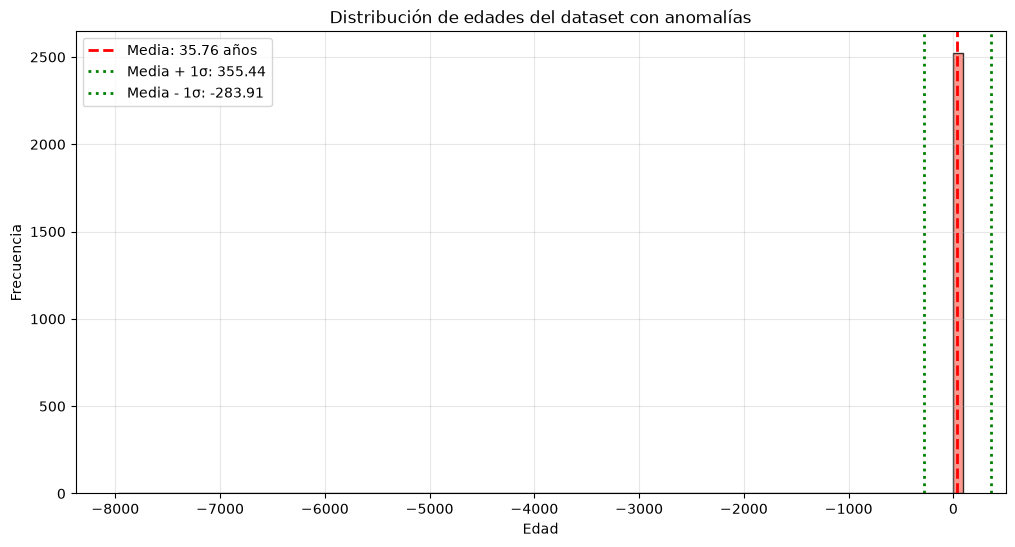

Media de edades con anomalías: 35.76 años
Desviación estándar con anomalías: 319.67 años
Número de valores negativos anómalos: 4
Valores negativos anómalos: [-7975.]


In [76]:
edades_con_anomalias = pd.to_numeric(df['edad'],errors='coerce').dropna()
media = np.mean(edades_con_anomalias)
desviacion = np.std(edades_con_anomalias, ddof=1)

plt.figure(figsize=(12, 6))
plt.hist(edades_con_anomalias, bins=80, color='salmon', edgecolor='black', alpha=0.8)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f} años')
plt.axvline(media + desviacion, color='green', linestyle=':', linewidth=2, label=f'Media + 1σ: {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='green', linestyle=':', linewidth=2, label=f'Media - 1σ: {media - desviacion:.2f}')
plt.title('Distribución de edades del dataset con anomalías')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'Media de edades con anomalías: {media:.2f} años')
print(f'Desviación estándar con anomalías: {desviacion:.2f} años')
print(f'Número de valores negativos anómalos: {(edades_con_anomalias < 0).sum()}')
print(f'Valores negativos anómalos: {edades_con_anomalias[edades_con_anomalias < 0].unique()}')

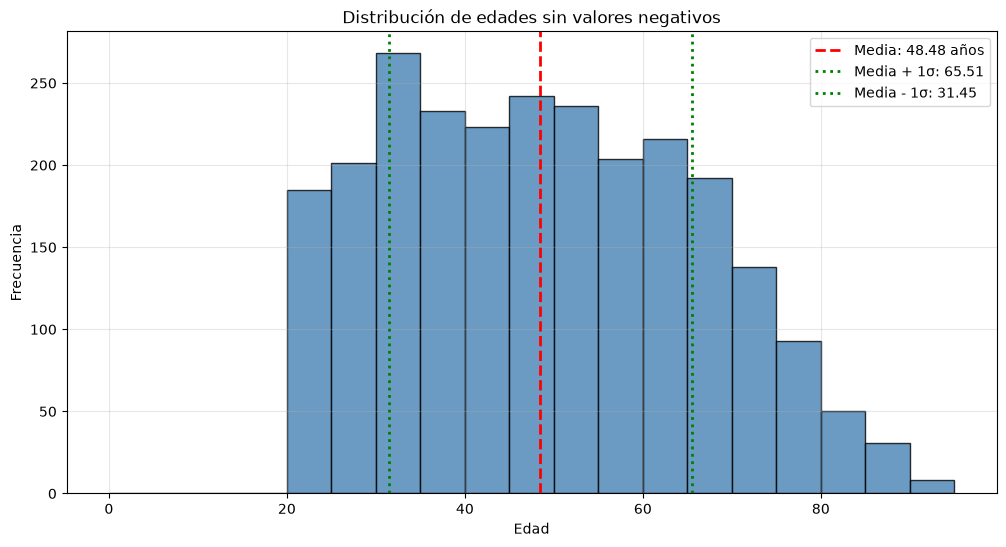

Registros negativos eliminados: 4
Media de edades: 48.48 años
Desviación estándar: 17.03 años
Cantidad de registros válidos usados: 2520


In [54]:
# Eliminar del dataset los registros con edad negativa
df['edad'] = pd.to_numeric(df['edad'], errors='coerce')
registros_negativos = (df['edad'] < 0).sum()
df = df[(df['edad'].isna()) | (df['edad'] >= 0)].copy()

# Calcular estadísticas de edad después de eliminar los valores negativos
edades_limpias = df['edad'].dropna()
media = np.mean(edades_limpias)
desviacion = np.std(edades_limpias, ddof=1)

plt.figure(figsize=(12, 6))
plt.hist(edades_limpias, bins=np.arange(0, edades_limpias.max() + 5, 5), color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f} años')
plt.axvline(media + desviacion, color='green', linestyle=':', linewidth=2, label=f'Media + 1σ: {media + desviacion:.2f}')
plt.axvline(media - desviacion, color='green', linestyle=':', linewidth=2, label=f'Media - 1σ: {media - desviacion:.2f}')
plt.title('Distribución de edades sin valores negativos')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'Registros negativos eliminados: {registros_negativos}')
print(f'Media de edades: {media:.2f} años')
print(f'Desviación estándar: {desviacion:.2f} años')
print(f'Cantidad de registros válidos usados: {len(edades_limpias)}')

Lo que se puede observar al comparar ambas gráficas es la importancia de identificar y tratar adecuadamente los valores anómalos dentro de un dataset. Resulta interesante observar cómo únicamente cuatro registros anómalos tienen un efecto considerable sobre los estadísticos de la variable, especialmente sobre la media y la desviación estándar. Debido a la gran distancia entre estos valores y el resto de las observaciones, la dispersión calculada aumenta considerablemente y deja de representar adecuadamente la distribución real de las edades de los participantes. Una vez tratados estos valores, la distribución y sus estadísticos descriptivos ofrecen una representación mucho más coherente de los datos.

#### Valores como object en lugar de valores númericos
Durante la exploración del dataset también se identificó un problema recurrente relacionado con los tipos de datos. Varias variables que, por su naturaleza, deberían ser numéricas fueron interpretadas como objetos (object). Esta inconsistencia puede estar relacionada con el formato utilizado durante la captura de los datos, particularmente con el uso de comas como separador decimal en lugar de puntos, lo que impide que estas variables sean reconocidas automáticamente como valores numéricos.

Esta situación representa un problema para el análisis, ya que mientras las variables permanezcan como objetos no es posible aplicar correctamente diferentes operaciones estadísticas y métodos de visualización propios de datos numéricos. Por esta razón, es necesario realizar una transformación previa, reemplazando el separador decimal y convirtiendo cada atributo al tipo de dato correspondiente.

In [55]:
# Convertir variables de texto a valores numéricos
variables_numericas = ['Peso', 'Estatura', 'ac_urico', 'albu', 'col_hdl', 'creat', 'insulina']
for variable in variables_numericas:
    df[variable] = pd.to_numeric(
        df[variable].astype(str).str.replace(',', '.', regex=False),
        errors='coerce'
    )

print('Tipos de datos después de la conversión:')
print(df[variables_numericas].dtypes)

# Descripción estadística de las variables ya convertidas
print('\nDescripción estadística de las variables numéricas tratadas:')
descripcion_estadistica = df[variables_numericas].describe()
descripcion_estadistica

Tipos de datos después de la conversión:
Peso        float64
Estatura    float64
ac_urico    float64
albu        float64
col_hdl     float64
creat       float64
insulina    float64
dtype: object

Descripción estadística de las variables numéricas tratadas:


,Peso,Estatura,ac_urico,albu,col_hdl,creat,insulina
count,1826.000000,1826.000000,2545.000000,2545.000000,2545.000000,2545.000000,2545.000000
mean,76.655285,159.758488,4.919961,3.425972,38.427191,0.733014,12.277760
std,21.044731,11.093068,1.442156,0.599867,10.689364,0.499632,15.385448
min,31.700000,126.500000,0.800000,1.100000,6.200000,0.200000,0.200000
25%,63.650000,152.500000,3.900000,3.000000,31.000000,0.560000,5.300000
50%,73.725000,158.850000,4.800000,3.500000,37.000000,0.670000,8.500000
75%,86.175000,165.675000,5.800000,3.800000,44.000000,0.810000,14.100000
max,222.220000,222.200000,16.400000,6.000000,98.000000,12.900000,395.000000


Una vez realizado la conversión de estas variables, es posible aprovechar los valores disponibles de peso y estatura para recuperar parte de la información faltante correspondiente al índice de masa corporal (IMC). Esta variable presenta la mayor cantidad de valores faltantes dentro del dataset; sin embargo, debido a que el IMC se calcula directamente a partir del peso y la estatura, es posible obtener su valor para aquellos participantes que cuenten con ambas mediciones. Esto permite reducir la cantidad de datos faltantes y recuperar información útil sin introducir valores estimados de manera arbitraria. 

In [56]:
# Calcular el IMC usando el peso en kg y la estatura en centímetros
registros_imc_validos = (
    df['Peso'].notna()
    & df['Estatura'].notna()
    & (df['Peso'] > 0)
    & (df['Estatura'] > 0)
)
df['imc_calculado'] = np.nan
df.loc[registros_imc_validos, 'imc_calculado'] = (
    df.loc[registros_imc_validos, 'Peso']
    / (df.loc[registros_imc_validos, 'Estatura'] / 100) ** 2
)

print(f'Participantes con IMC calculado: {registros_imc_validos.sum()}')
print('\nDescripción estadística del IMC calculado:')
print(df.loc[registros_imc_validos, 'imc_calculado'].describe())

Participantes con IMC calculado: 1826

Descripción estadística del IMC calculado:
count    1826.000000
mean       29.854564
std         6.165534
min        12.446114
25%        25.791560
50%        29.023382
75%        33.165335
max        65.552663
Name: imc_calculado, dtype: float64


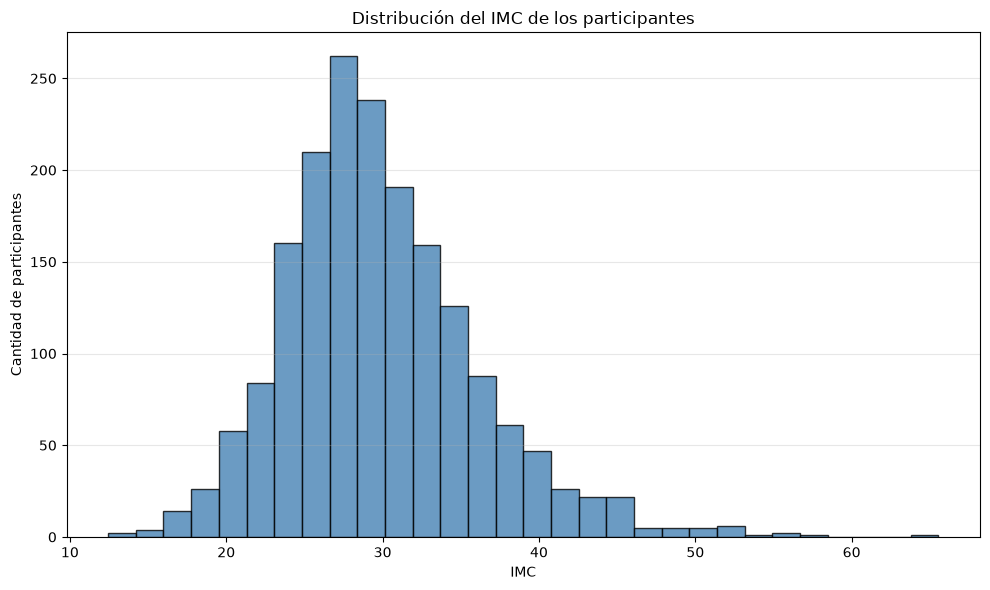

In [57]:
# Histograma del IMC calculado
imc_validos = df['imc_calculado'].dropna()

plt.figure(figsize=(10, 6))
plt.hist(imc_validos, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Distribución del IMC de los participantes')
plt.xlabel('IMC')
plt.ylabel('Cantidad de participantes')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Después de calcular el IMC a partir de los valores disponibles de peso y estatura, fue posible recuperar esta información para 1,829 participantes. El análisis descriptivo muestra un IMC promedio de 29.85 kg/m², mientras que la mediana es de 29.03 kg/m². La cercanía entre ambas medidas indica que la mayor parte de los datos se concentra alrededor de valores similares, aunque el histograma muestra una ligera asimetría hacia la derecha debido a la presencia de valores elevados.

### Anális bivariado

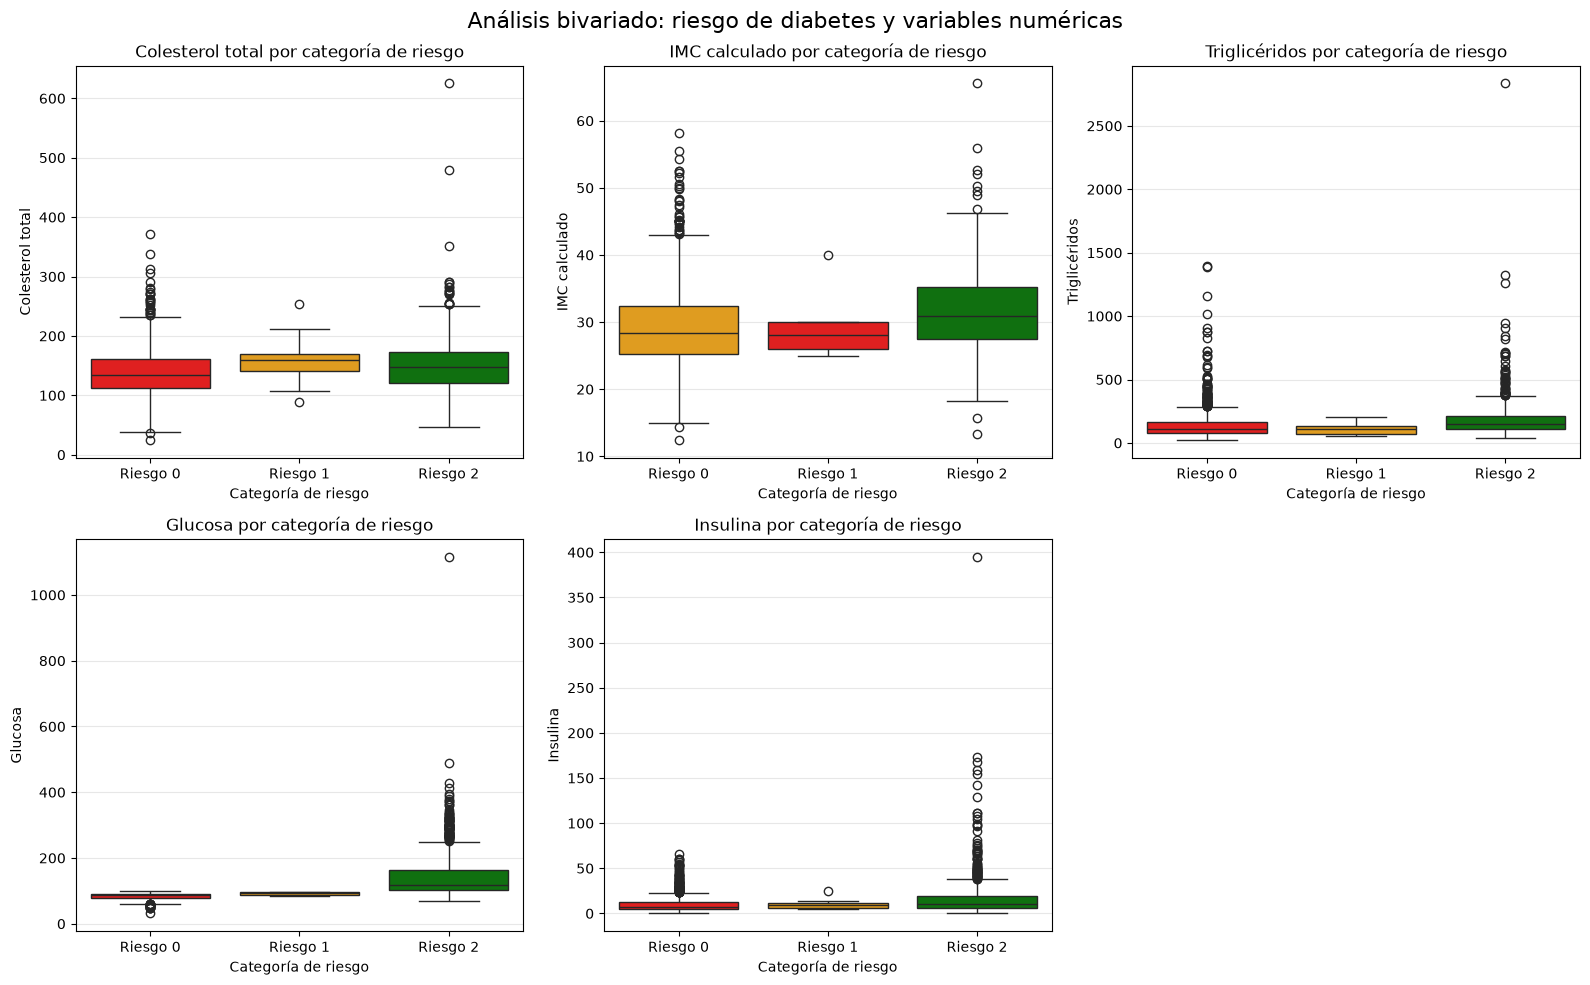

Cantidad de observaciones utilizadas en cada boxplot:
riesgo            Riesgo 0  Riesgo 1  Riesgo 2
Colesterol total      1694        12       839
IMC calculado         1323         9       494
Triglicéridos         1694        12       839
Glucosa               1694        12       839
Insulina              1694        12       839


In [58]:
# Boxplots del riesgo de diabetes frente a variables numéricas
variables_bivariado = {
    'Colesterol total': df['colest'],
    'IMC calculado': df['imc_calculado'],
    'Triglicéridos': df['trig'],
    'Glucosa': df['glu_suero'],
    'Insulina': df['insulina']
}

boxplot_data = pd.DataFrame({
    'riesgo': pd.to_numeric(df['riesgo_diabetes_cat'], errors='coerce')
})

for nombre, valores in variables_bivariado.items():
    if nombre == 'IMC calculado':
        boxplot_data[nombre] = valores
    else:
        boxplot_data[nombre] = pd.to_numeric(
            valores.astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )

boxplot_data = boxplot_data.dropna(subset=['riesgo'])
boxplot_data = boxplot_data[boxplot_data['riesgo'].isin([0, 1, 2])]
boxplot_data['riesgo'] = boxplot_data['riesgo'].map({
    0: 'Riesgo 0',
    1: 'Riesgo 1',
    2: 'Riesgo 2'
})

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for indice, (nombre, valores) in enumerate(variables_bivariado.items()):
    datos_grafica = boxplot_data[['riesgo', nombre]].dropna()
    sns.boxplot(
        data=datos_grafica,
        x='riesgo',
        y=nombre,
        hue='riesgo',
        order=['Riesgo 0', 'Riesgo 1', 'Riesgo 2'],
        palette=['green', 'orange', 'red'],
        legend=False,
        ax=axes[indice]
    )
    axes[indice].set_title(f'{nombre} por categoría de riesgo')
    axes[indice].set_xlabel('Categoría de riesgo')
    axes[indice].set_ylabel(nombre)
    axes[indice].tick_params(axis='x', rotation=0)
    axes[indice].grid(axis='y', alpha=0.3)

axes[-1].axis('off')
plt.suptitle('Análisis bivariado: riesgo de diabetes y variables numéricas', fontsize=16)
plt.tight_layout()
plt.show()

print('Cantidad de observaciones utilizadas en cada boxplot:')
print(boxplot_data.groupby('riesgo', observed=True).count().T)

El análisis bivariado permite observar diferencias en la distribución de algunas variables según la categoría de riesgo de diabetes. En general, los participantes clasificados como Riesgo 2 presentan valores centrales más elevados de IMC, triglicéridos, glucosa e insulina. 

La glucosa es la variable en la que se aprecia una de las diferencias más claras. Riesgo 0 y Riesgo 1 presentan distribuciones relativamente concentradas y con valores centrales similares, mientras que Riesgo 2 muestra una mediana notablemente mayor, una mayor dispersión y numerosos valores elevados. Visualmente, esta variable parece mostrar una relación más marcada con la clasificación de riesgo que el colesterol total. No obstante, también se observa un valor extremadamente alto, superior a 1000, que debería revisarse para determinar si corresponde a una medición válida o a un posible error.

Las observaciones correspondientes a Riesgo 1 deben analizarse con precaución debido al reducido número de participantes en esta categoría. En conjunto, estos resultados sugieren que algunas variables presentan una relación más marcada con la categoría de riesgo.

### Vista multivariada

Matriz de correlación:


,riesgo_diabetes_cat,imc_calculado,glu_suero,trig,colest,col_hdl,col_ldl,insulina
riesgo_diabetes_cat,1.000000,0.193198,0.551437,0.172701,0.145670,-0.023267,0.125953,0.260864
imc_calculado,0.193198,1.000000,0.082239,0.087326,0.022842,-0.186961,0.082507,0.294713
glu_suero,0.551437,0.082239,1.000000,0.184218,0.169741,0.002909,0.137104,0.097080
trig,0.172701,0.087326,0.184218,1.000000,0.456319,-0.123357,0.235179,0.102933
colest,0.145670,0.022842,0.169741,0.456319,1.000000,0.477170,0.896011,0.027061
col_hdl,-0.023267,-0.186961,0.002909,-0.123357,0.477170,1.000000,0.340286,-0.077434
col_ldl,0.125953,0.082507,0.137104,0.235179,0.896011,0.340286,1.000000,0.036379
insulina,0.260864,0.294713,0.097080,0.102933,0.027061,-0.077434,0.036379,1.000000


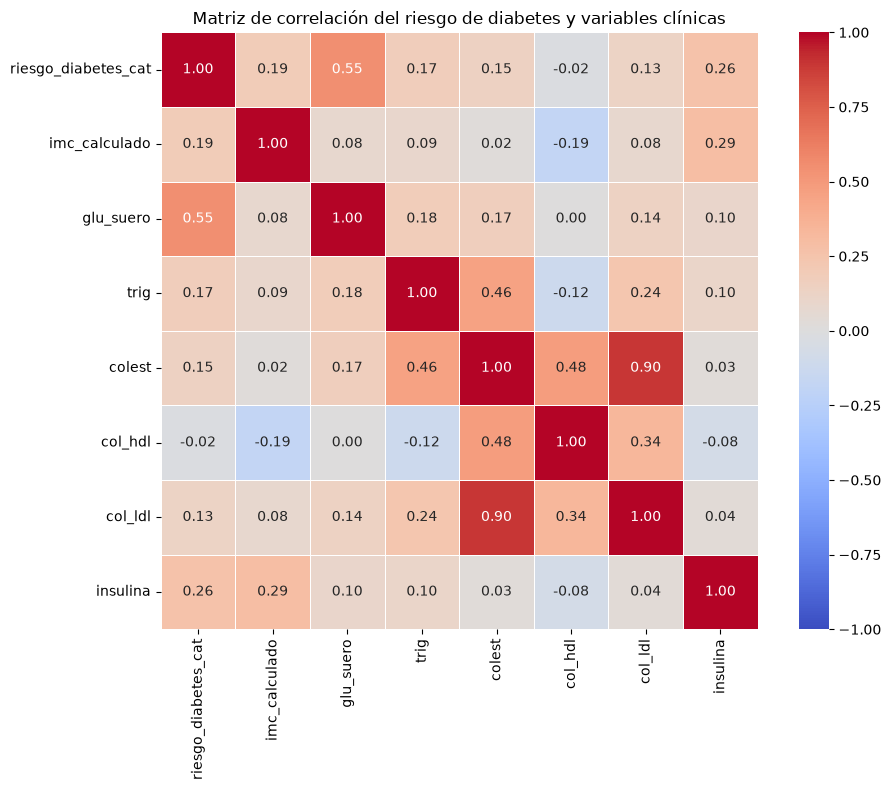

In [46]:
# Matriz de correlación del riesgo de diabetes con variables clínicas
variables_correlacion = [
    'riesgo_diabetes_cat',
    'imc_calculado',
    'glu_suero',
    'trig',
    'colest',
    'col_hdl',
    'col_ldl',
    'insulina'
]

correlacion_data = pd.DataFrame(index=df.index)
for variable in variables_correlacion:
    if variable == 'imc_calculado':
        correlacion_data[variable] = df[variable]
    else:
        correlacion_data[variable] = pd.to_numeric(
            df[variable].astype(str).str.replace(',', '.', regex=False),
            errors='coerce'
        )

correlacion_data = correlacion_data.dropna()
matriz_correlacion = correlacion_data.corr()

print('Matriz de correlación:')
display(matriz_correlacion)

plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Matriz de correlación del riesgo de diabetes y variables clínicas')
plt.tight_layout()
plt.show()

La matriz de correlación permite identificar las relaciones lineales entre las variables clínicas analizadas. La relación más fuerte se presenta entre el colesterol total y el colesterol LDL, con una correlación positiva de 0.90, lo que indica que ambas variables tienden a aumentar conjuntamente. También se observan correlaciones moderadas entre colesterol total y HDL (0.48) y entre colesterol total y triglicéridos (0.46).

Respecto a la variable objetivo, la glucosa en suero presenta la correlación más alta con la categoría de riesgo de diabetes (0.55). El resto de las variables muestran asociaciones más débiles, como insulina (0.26), IMC (0.19) y triglicéridos (0.17). En general, la matriz muestra que la mayoría de las relaciones entre las variables seleccionadas son débiles o moderadas, con excepción de la relación entre colesterol total y LDL.

### Conclusiones
El análisis exploratorio permitió conocer la estructura, calidad y principales características del dataset, así como identificar diferentes aspectos que debían ser tratados antes de realizar una interpretación adecuada de los datos. Entre los principales problemas encontrados se encuentran la presencia de valores faltantes, registros fuera de rango y variables numéricas almacenadas como objetos, estas últimas posiblemente debido al uso de comas como separador decimal. La corrección de estas inconsistencias permitió trabajar adecuadamente con las variables y obtener estadísticas y visualizaciones más representativas.

Uno de los casos más evidentes fue la variable edad, en la que se encontraron valores negativos de gran magnitud que afectaban considerablemente sus estadísticos descriptivos, particularmente la media y la desviación estándar. Su identificación y tratamiento demostraron la importancia de revisar la calidad de los datos antes de realizar cualquier análisis estadístico. Asimismo, se logró recuperar información del IMC mediante su cálculo a partir del peso y la estatura disponibles, que originalmnete estaban alamcenadas como objeto pero se hizo el cambio a variables númericas.

El análisis de la variable objetivo mostró un desbalance importante entre las categorías de riesgo de diabetes, por lo que las comparaciones entre grupos deben interpretarse con precaución, especialmente para la categoría Riesgo 1 debido a su reducido número de observaciones. El análisis multivariado permitió identificar diferentes grados de relación entre las variables clínicas. La correlación más elevada se presentó entre el colesterol total y el colesterol LDL (0.90), que realmente es un patron esperado debido a la naturaleza de estas variables que se encuentran fisiológicamente relacionadas. Por otra parte, la glucosa presentó la mayor asociación exploratoria con la categoría objectivo que es el riesgo de diabetes (0.55). 

Finalmente, debido a las constantes inconsistencias encontradas en el dataset, fue necesario realizar procesos de limpieza y tratamiento antes de llevar a cabo el análisis. Estas modificaciones permitieron corregir algunos de los principales problemas de calidad e identificar patrones relevantes relacionados con el riesgo de diabetes. Si bien podrían aplicarse tratamientos adicionales, se realizaron únicamente aquellos considerados esenciales para comprender y analizar los datos. Aun así, los resultados deben interpretarse considerando limitaciones como los valores faltantes, el desbalance entre categorías y la presencia de valores extremos.

### Referencias
De Santiago Nocito, A. (2010). Definición, clasificación clínica y diagnóstico de la diabetes mellitus. Documentos clinicos SEMERGEN.

Reyes-García, A., Basto-Abreu, A., Reyes-Sánchez, F., Stern, D., Romero-Martínez, M., Campos-Nonato, I., Rojas-Martínez, R., Aguilar-Salinas, C. A., & Barrientos-Gutiérrez, T. (2025). Prevalencia de diabetes y control glucémico en México, Ensanut 2021-2024. Salud Pública de México, 67(6 (nov-dic)), 622-632. https://doi.org/10.21149/17286 

Encuesta Nacional de Salud y Nutrición. (2024). ENCUESTAS. https://ensanut.insp.mx/encuestas/ensanutcontinua2024/descargas.php

Hernández-Ávila, M., Gutiérrez, J. P., & Reynoso-Noverón, N. (2013). Diabetes mellitus en México: El estado de la epidemia. Salud pública de México, 55, s129-s136. 

Axel Frederick Félix Jiménez, and Vania Stephany Sánchez Lee. (2026). Diabetes Mexico Data Set [Dataset]. Kaggle. https://doi.org/10.34740/KAGGLE/DSV/14619160 